# Линейная алгебра, математический анализ

Исследовательское задание: малоранговая аппроксимация матрицы. Сгенерируйте случайную квадратную матрицу A ∈ R
n×n, n ≥ 100. С помощью функции numpy.linalg.svd выполните сингулярное разложение этой матрицы, и получите три матрицы: U, S, V
⊤. Выполняйте аппроксимацию матрицы A с
рангом r, меняя его значение, например, от 2 до n:
A˜ = U[:, : r]S[: r, : r]V
⊤[: r, :],
и каждый раз считайте ошибку апроксимации (как восстановленная матрица отличается от исходной):
E(r) = ||A − A˜||F =
vuut
Xn
i=1
Xn
j=1
(aij − a˜ij )
2.
Используя библиотеку matplotlib, постройте график зависимости ошибки аппроксимации матрицы от
ранга r.

<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/var/folders/37/bg5czn2n66v4cmr35njrnt7r0000gn/T/ipykernel_52545/1143050321.py:45: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Сингулярное число $\sigma_i$', fontsize=12)


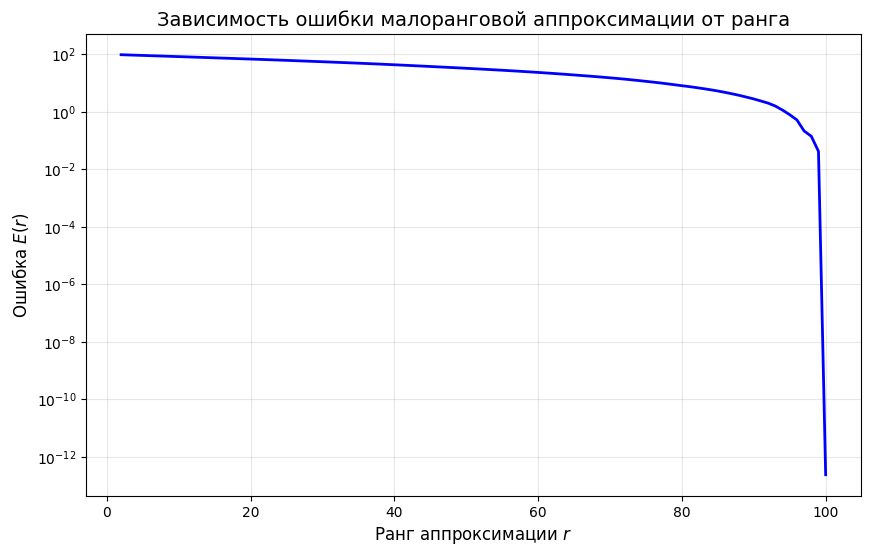

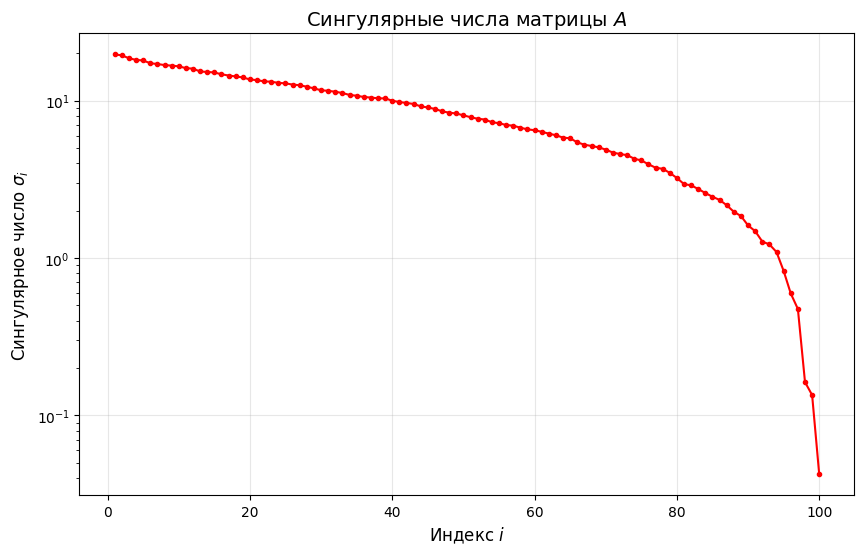

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Параметры
n = 100  # размер матрицы
np.random.seed(42)  # для воспроизводимости

# 2. Генерация случайной матрицы
A = np.random.randn(n, n)

# 3. SVD
U, S_diag, VT = np.linalg.svd(A, full_matrices=True)

S = np.diag(S_diag)  # делаем диагональную матрицу размера n x n
# U: (n, n), S: (n, n), VT: (n, n)

# 4. Вычисление ошибок для разных r
errors = []
ranks = list(range(2, n+1))

for r in ranks:
    # Аппроксимация ранга r
    U_r = U[:, :r]
    S_r = S[:r, :r]
    VT_r = VT[:r, :]
    A_approx = U_r @ S_r @ VT_r  # A_tilde

    error = np.linalg.norm(A - A_approx, 'fro')
    errors.append(error)

# 5. График
plt.figure(figsize=(10, 6))
plt.plot(ranks, errors, 'b-', linewidth=2)
plt.xlabel('Ранг аппроксимации $r$', fontsize=12)
plt.ylabel('Ошибка $E(r)$', fontsize=12)
plt.title('Зависимость ошибки малоранговой аппроксимации от ранга', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()